In [1]:
!pip install datasets

In [2]:
import datasets
import huggingface_hub

print("datasets version:", datasets.__version__)
print("huggingface_hub version:", huggingface_hub.__version__)

C:\Users\PAVITHRA\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


datasets version: 5.0.1
huggingface_hub version: 1.27.0


In [3]:
pip uninstall datasets huggingface_hub -y

Found existing installation: datasets 5.0.1
Uninstalling datasets-5.0.1:
  Successfully uninstalled datasets-5.0.1
Found existing installation: huggingface_hub 1.27.0
Uninstalling huggingface_hub-1.27.0:
  Successfully uninstalled huggingface_hub-1.27.0
Note: you may need to restart the kernel to use updated packages.


In [4]:
!python -m pip install -U datasets huggingface_hub

  Using cached datasets-5.0.1-py3-none-any.whl.metadata (23 kB)
  Using cached huggingface_hub-1.27.0-py3-none-any.whl.metadata (16 kB)
Using cached datasets-5.0.1-py3-none-any.whl (559 kB)
Using cached huggingface_hub-1.27.0-py3-none-any.whl (784 kB)

   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   ---------------------------------------- 0/2 [huggingface_hub]
   -------------------- ------------------- 1/2 [datasets]
   -------------------- ------------------- 1/2 [datasets]
   -------------------- ------------------- 1/2 [datasets]
   -------------------- ------------------

In [5]:
!python -m pip install -U datasets huggingface_hub

In [6]:
!python -m pip install -U fsspec

  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.6.0
    Uninstalling fsspec-2026.6.0:
      Successfully uninstalled fsspec-2026.6.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 5.0.1 requires fsspec[http]<=2026.6.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.


In [7]:
!python -m pip install "fsspec[http]==2026.6.0"

  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
Using cached fsspec-2026.6.0-py3-none-any.whl (203 kB)
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.7.0
    Uninstalling fsspec-2026.7.0:
      Successfully uninstalled fsspec-2026.7.0


In [8]:
import datasets
import fsspec
import huggingface_hub

print("datasets:", datasets.__version__)
print("fsspec:", fsspec.__version__)
print("huggingface_hub:", huggingface_hub.__version__)

datasets: 5.0.1
fsspec: 2026.6.0
huggingface_hub: 1.27.0


In [9]:
from datasets import load_dataset

dataset = load_dataset("sh0416/ag_news")

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU
from tensorflow.keras.layers import Bidirectional, Dense

from tensorflow.keras.optimizers import Adam

In [11]:
os.makedirs("plots", exist_ok=True)

In [12]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})


In [13]:
print("Training samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))

Training samples: 120000
Test samples: 7600


In [14]:
from datasets import load_dataset

dataset = load_dataset("sh0416/ag_news")

In [15]:
from datasets import load_dataset

dataset = load_dataset("sh0416/ag_news")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['label', 'title', 'description'],
        num_rows: 7600
    })
})


In [16]:
print("Training samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))

Training samples: 120000
Test samples: 7600


In [17]:
print(dataset["train"].column_names)

['label', 'title', 'description']


In [18]:
print(dataset["train"][0])

{'label': 3, 'title': 'Wall St. Bears Claw Back Into the Black (Reuters)', 'description': "Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again."}


In [19]:
for i in range(5):
    print("Article:", dataset["train"][i]["description"])
    print("Label:", dataset["train"][i]["label"])
    print("-" * 80)

Article: Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.
Lab

In [20]:
for i in range(5):
    print("Article:", dataset["train"][i]["description"])
    print("Label:", dataset["train"][i]["label"])
    print("-" * 80)

Article: Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums.
Label: 3
--------------------------------------------------------------------------------
Article: Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday.
Lab

In [21]:
import pandas as pd
train_labels = dataset["train"]["label"]

print(pd.Series(train_labels).value_counts().sort_index())

1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [22]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [23]:
print(sorted(set(train_labels)))

[1, 2, 3, 4]


In [24]:
print(pd.Series(train_labels).value_counts().sort_index())

1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [25]:
print(dataset["train"].features)

{'label': Value('int64'), 'title': Value('string'), 'description': Value('string')}


In [26]:
print(sorted(set(train_labels)))

[1, 2, 3, 4]


In [27]:
print(dataset["train"].features)

{'label': Value('int64'), 'title': Value('string'), 'description': Value('string')}


In [28]:
label_mapping = {
    1: 0,
    2: 1,
    3: 2,
    4: 3
}

train_labels = [label_mapping[x] for x in dataset["train"]["label"]]
test_labels = [label_mapping[x] for x in dataset["test"]["label"]]

In [29]:
print(sorted(set(train_labels)))

[0, 1, 2, 3]


In [30]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

In [31]:
class_counts = pd.Series(train_labels).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "Label": class_counts.index,
    "Category": [label_names[i] for i in class_counts.index],
    "Count": class_counts.values
})

print(class_distribution)

   Label  Category  Count
0      0     World  30000
1      1    Sports  30000
2      2  Business  30000
3      3  Sci/Tech  30000


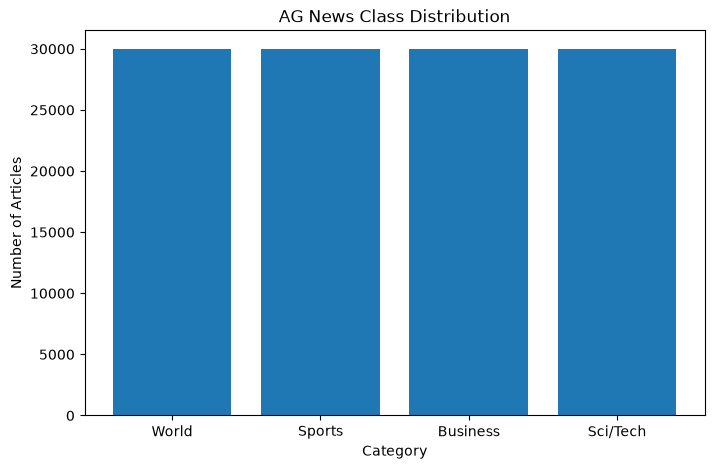

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    class_distribution["Category"],
    class_distribution["Count"]
)

plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.title("AG News Class Distribution")

plt.savefig("plots/class_distribution.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [33]:
train_text = [
    title + " " + description
    for title, description in zip(
        dataset["train"]["title"],
        dataset["train"]["description"]
    )
]

test_text = [
    title + " " + description
    for title, description in zip(
        dataset["test"]["title"],
        dataset["test"]["description"]
    )
]

In [34]:
print(train_text[0])
print("Label:", train_labels[0])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.
Label: 2


In [35]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [36]:
MAX_WORDS = 20000

In [37]:
tokenizer = Tokenizer(num_words=MAX_WORDS)

In [38]:
tokenizer.fit_on_texts(train_text)

In [39]:
X_train_seq = tokenizer.texts_to_sequences(train_text)
X_test_seq = tokenizer.texts_to_sequences(test_text)

In [40]:
print(X_train_seq[0][:30])

[442, 441, 1681, 14528, 108, 64, 1, 850, 21, 21, 753, 8196, 442, 6640, 10231, 2927, 4, 5810, 40, 4049, 797, 332]


In [41]:
print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 70344


In [42]:
num_words=20000

In [43]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [44]:
MAX_LEN = 100

In [45]:
X_train = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [46]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120000, 100)
X_test shape: (7600, 100)
y_train shape: (120000,)
y_test shape: (7600,)


In [48]:
print("Training labels:", np.unique(y_train))
print("Test labels:", np.unique(y_test))

Training labels: [0 1 2 3]
Test labels: [0 1 2 3]


Text Preprocessing:
The title and description fields were combined into a single text input. The Keras tokenizer was configured with a vocabulary size of 20,000 words and used to convert the news articles into integer sequences. The sequences were padded or truncated to a maximum length of 100 tokens. Finally, the labels were converted into NumPy arrays for model training.

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [50]:
model_rnn = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),
    
    SimpleRNN(64),
    
    Dense(32, activation="relu"),
    
    Dense(4, activation="softmax")
])

In [51]:
input_length=MAX_LEN

In [52]:
model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [53]:
model_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [54]:
rnn_test_loss, rnn_test_accuracy = model_rnn.evaluate(
    X_test,
    y_test
)

print("Simple RNN Test Loss:", rnn_test_loss)
print("Simple RNN Test Accuracy:", rnn_test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2568 - loss: 1.3881
Simple RNN Test Loss: 1.3880712985992432
Simple RNN Test Accuracy: 0.25684210658073425


In [55]:
print("history_rnn" in globals())

False


In [56]:
import time

start_time = time.time()

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

rnn_time = time.time() - start_time

print("Training time:", rnn_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.7136 - loss: 0.7825 - val_accuracy: 0.4787 - val_loss: 1.0649
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 57s 75ms/step - accuracy: 0.4653 - loss: 1.0919 - val_accuracy: 0.2594 - val_loss: 1.3852
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 63s 84ms/step - accuracy: 0.2672 - loss: 1.3671 - val_accuracy: 0.4067 - val_loss: 1.1512
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.6906 - loss: 0.8422 - val_accuracy: 0.6850 - val_loss: 0.9020
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 60s 80ms/step - accuracy: 0.7821 - loss: 0.6719 - val_accuracy: 0.7266 - val_loss: 0.8009
Training time: 297.99809432029724 seconds


In [57]:
print(history_rnn.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


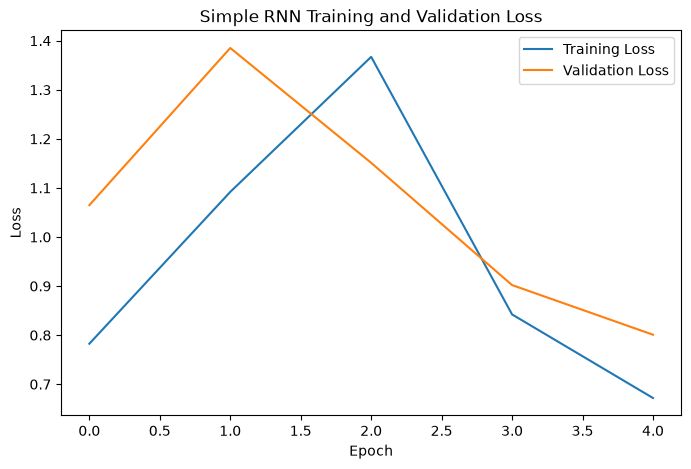

In [58]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN Training and Validation Loss")
plt.legend()

plt.savefig("plots/rnn_loss.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

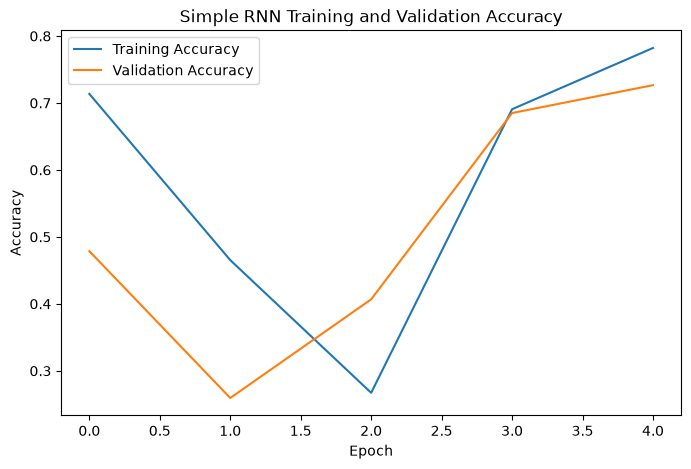

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_rnn.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Simple RNN Training and Validation Accuracy")
plt.legend()

plt.savefig("plots/rnn_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close()

In [60]:
rnn_test_loss, rnn_test_accuracy = model_rnn.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Simple RNN Test Loss:", rnn_test_loss)
print("Simple RNN Test Accuracy:", rnn_test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7480 - loss: 0.7474
Simple RNN Test Loss: 0.7474215030670166
Simple RNN Test Accuracy: 0.7480263113975525


In [61]:
rnn_time

297.99809432029724

In [62]:
print("Simple RNN Training Time:", rnn_time, "seconds")

Simple RNN Training Time: 297.99809432029724 seconds


In [63]:
from tensorflow.keras.layers import LSTM

In [64]:
model_lstm = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),
    
    LSTM(64),
    
    Dense(32, activation="relu"),
    
    Dense(4, activation="softmax")
])

In [65]:
model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [66]:
model_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
start_time = time.time()

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

lstm_time = time.time() - start_time

print("LSTM Training Time:", lstm_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 119s 154ms/step - accuracy: 0.2516 - loss: 1.3882 - val_accuracy: 0.2445 - val_loss: 1.3867
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 151ms/step - accuracy: 0.5667 - loss: 0.8821 - val_accuracy: 0.8928 - val_loss: 0.3429
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 105s 141ms/step - accuracy: 0.9222 - loss: 0.2598 - val_accuracy: 0.9054 - val_loss: 0.2946
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 100s 133ms/step - accuracy: 0.9475 - loss: 0.1761 - val_accuracy: 0.8982 - val_loss: 0.3380
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 101s 135ms/step - accuracy: 0.9602 - loss: 0.1280 - val_accuracy: 0.8977 - val_loss: 0.3586
LSTM Training Time: 538.7103078365326 seconds


In [68]:
lstm_test_loss, lstm_test_accuracy = model_lstm.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9050 - loss: 0.3394
LSTM Test Loss: 0.3393799662590027
LSTM Test Accuracy: 0.9049999713897705


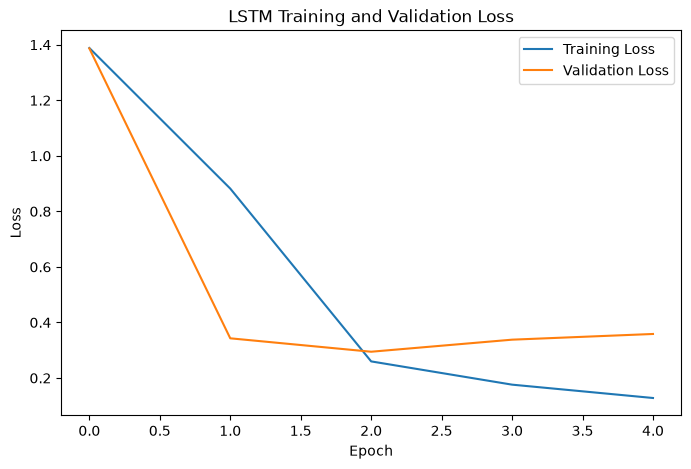

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")
plt.legend()

plt.savefig(
    "plots/lstm_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

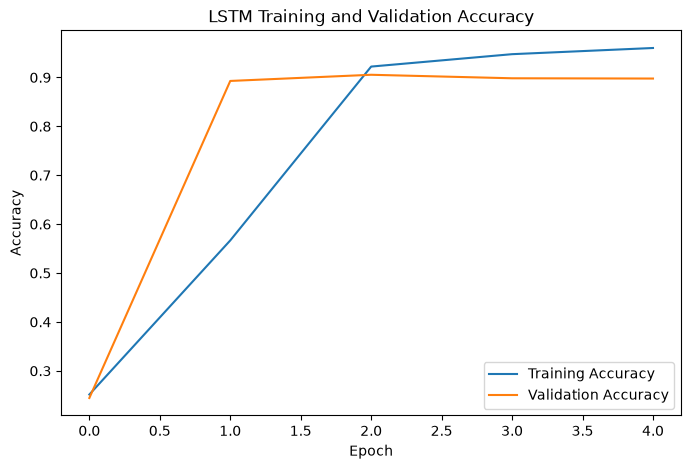

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_lstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_lstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Training and Validation Accuracy")
plt.legend()

plt.savefig(
    "plots/lstm_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [71]:
from tensorflow.keras.layers import GRU

In [72]:
model_gru = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),
    
    GRU(64),
    
    Dense(32, activation="relu"),
    
    Dense(4, activation="softmax")
])

In [73]:
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [74]:
model_gru.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [75]:
start_time = time.time()

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

gru_time = time.time() - start_time

print("GRU Training Time:", gru_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 97s 126ms/step - accuracy: 0.2522 - loss: 1.3857 - val_accuracy: 0.2444 - val_loss: 1.3863
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.2521 - loss: 1.3844 - val_accuracy: 0.2442 - val_loss: 1.3854
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 96s 128ms/step - accuracy: 0.2804 - loss: 1.3498 - val_accuracy: 0.6217 - val_loss: 0.8338
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 97s 130ms/step - accuracy: 0.8825 - loss: 0.3495 - val_accuracy: 0.9032 - val_loss: 0.2832
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 98s 131ms/step - accuracy: 0.9371 - loss: 0.1965 - val_accuracy: 0.9085 - val_loss: 0.2663
GRU Training Time: 484.4748578071594 seconds


In [76]:
gru_test_loss, gru_test_accuracy = model_gru.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("GRU Test Loss:", gru_test_loss)
print("GRU Test Accuracy:", gru_test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9142 - loss: 0.2550
GRU Test Loss: 0.25501054525375366
GRU Test Accuracy: 0.9142104983329773


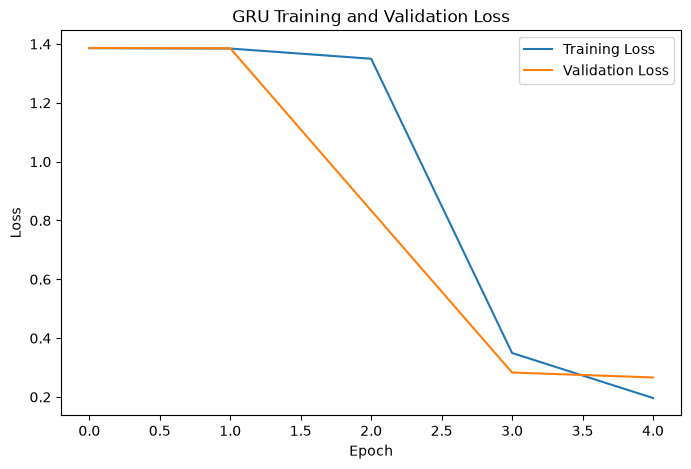

In [77]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()

plt.savefig(
    "plots/gru_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

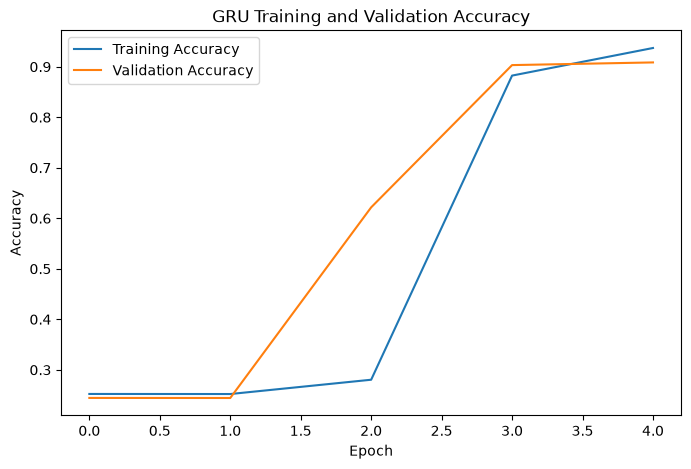

In [78]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_gru.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_gru.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()

plt.savefig(
    "plots/gru_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [79]:
comparison = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "GRU"],
    "Test Accuracy": [
        rnn_test_accuracy,
        lstm_test_accuracy,
        gru_test_accuracy
    ],
    "Training Time (seconds)": [
        rnn_time,
        lstm_time,
        gru_time
    ]
})

print(comparison)

        Model  Test Accuracy  Training Time (seconds)
0  Simple RNN       0.748026               297.998094
1        LSTM       0.905000               538.710308
2         GRU       0.914210               484.474858


In [80]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [81]:
from tensorflow.keras.layers import Bidirectional

In [82]:
model_bilstm = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    Bidirectional(
        LSTM(64)
    ),

    Dense(32, activation="relu"),

    Dense(4, activation="softmax")
])

In [83]:
model_bilstm.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [84]:
model_bilstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [85]:
start_time = time.time()

history_bilstm = model_bilstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

bilstm_time = time.time() - start_time

print("Bi-LSTM Training Time:", bilstm_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 151s 198ms/step - accuracy: 0.8766 - loss: 0.3555 - val_accuracy: 0.9086 - val_loss: 0.2659
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 140s 187ms/step - accuracy: 0.9383 - loss: 0.1857 - val_accuracy: 0.9063 - val_loss: 0.2736
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 144s 192ms/step - accuracy: 0.9522 - loss: 0.1382 - val_accuracy: 0.9007 - val_loss: 0.3016
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 138s 183ms/step - accuracy: 0.9632 - loss: 0.1036 - val_accuracy: 0.8968 - val_loss: 0.3457
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 189ms/step - accuracy: 0.9715 - loss: 0.0784 - val_accuracy: 0.8917 - val_loss: 0.3830
Bi-LSTM Training Time: 714.5242116451263 seconds


In [86]:
bilstm_test_loss, bilstm_test_accuracy = model_bilstm.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Bi-LSTM Test Loss:", bilstm_test_loss)
print("Bi-LSTM Test Accuracy:", bilstm_test_accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.9083 - loss: 0.3308
Bi-LSTM Test Loss: 0.3307906687259674
Bi-LSTM Test Accuracy: 0.9082894921302795


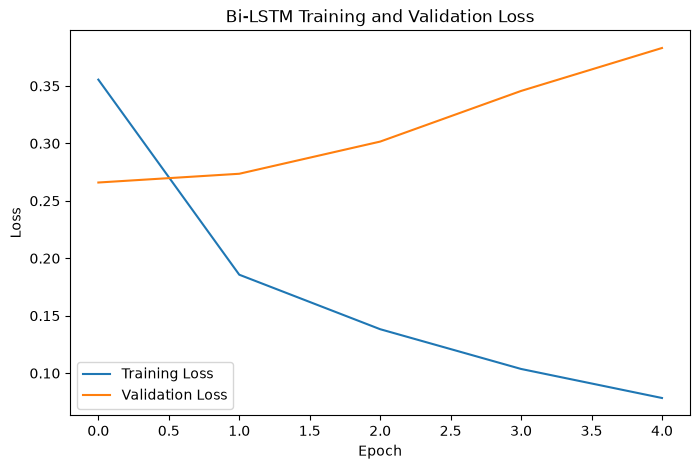

In [87]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bilstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_bilstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Bi-LSTM Training and Validation Loss")
plt.legend()

plt.savefig(
    "plots/bilstm_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

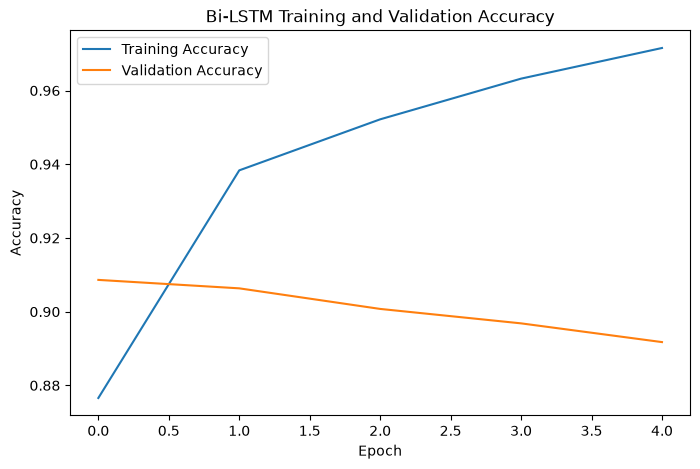

In [88]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_bilstm.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_bilstm.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Bi-LSTM Training and Validation Accuracy")
plt.legend()

plt.savefig(
    "plots/bilstm_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [89]:
comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU",
        "Bi-LSTM"
    ],
    "Test Accuracy": [
        rnn_test_accuracy,
        lstm_test_accuracy,
        gru_test_accuracy,
        bilstm_test_accuracy
    ],
    "Training Time (seconds)": [
        rnn_time,
        lstm_time,
        gru_time,
        bilstm_time
    ]
})

print(comparison)

        Model  Test Accuracy  Training Time (seconds)
0  Simple RNN       0.748026               297.998094
1        LSTM       0.905000               538.710308
2         GRU       0.914210               484.474858
3     Bi-LSTM       0.908289               714.524212


In [90]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [91]:
best_model = comparison.loc[
    comparison["Test Accuracy"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model                             GRU
Test Accuracy                 0.91421
Training Time (seconds)    484.474858
Name: 2, dtype: object


In [92]:
from tensorflow.keras.optimizers import Adam

In [93]:
model_lstm_no_clip = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    LSTM(64),

    Dense(32, activation="relu"),

    Dense(4, activation="softmax")
])

In [94]:
model_lstm_no_clip.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
start_time = time.time()

history_no_clip = model_lstm_no_clip.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

no_clip_time = time.time() - start_time

print("LSTM without clipping:", no_clip_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 118ms/step - accuracy: 0.2519 - loss: 1.3867 - val_accuracy: 0.2350 - val_loss: 1.3852
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 91s 121ms/step - accuracy: 0.2719 - loss: 1.3509 - val_accuracy: 0.4704 - val_loss: 0.9575
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 93s 124ms/step - accuracy: 0.7744 - loss: 0.5058 - val_accuracy: 0.8993 - val_loss: 0.3023
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9293 - loss: 0.2282 - val_accuracy: 0.9053 - val_loss: 0.2743
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 100s 133ms/step - accuracy: 0.9480 - loss: 0.1684 - val_accuracy: 0.9057 - val_loss: 0.2933
LSTM without clipping: 463.5025324821472 seconds


In [96]:
model_lstm_clip = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128
    ),

    LSTM(64),

    Dense(32, activation="relu"),

    Dense(4, activation="softmax")
])

In [97]:
optimizer_clip = Adam(clipnorm=1.0)

In [98]:
model_lstm_clip.compile(
    optimizer=optimizer_clip,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [99]:
start_time = time.time()

history_clip = model_lstm_clip.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)

clip_time = time.time() - start_time

print("LSTM with clipping:", clip_time, "seconds")

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 101s 131ms/step - accuracy: 0.2751 - loss: 1.3621 - val_accuracy: 0.4445 - val_loss: 1.0932
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 111s 148ms/step - accuracy: 0.8301 - loss: 0.4562 - val_accuracy: 0.9042 - val_loss: 0.3036
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 100s 133ms/step - accuracy: 0.9358 - loss: 0.2179 - val_accuracy: 0.9038 - val_loss: 0.3107
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 89s 118ms/step - accuracy: 0.9514 - loss: 0.1635 - val_accuracy: 0.8994 - val_loss: 0.3371
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.9632 - loss: 0.1253 - val_accuracy: 0.8958 - val_loss: 0.3836
LSTM with clipping: 488.91214084625244 seconds


In [100]:
no_clip_loss, no_clip_accuracy = model_lstm_no_clip.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Without clipping accuracy:", no_clip_accuracy)

Without clipping accuracy: 0.913947343826294


In [101]:
clip_loss, clip_accuracy = model_lstm_clip.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("With clipping accuracy:", clip_accuracy)

With clipping accuracy: 0.9073684215545654


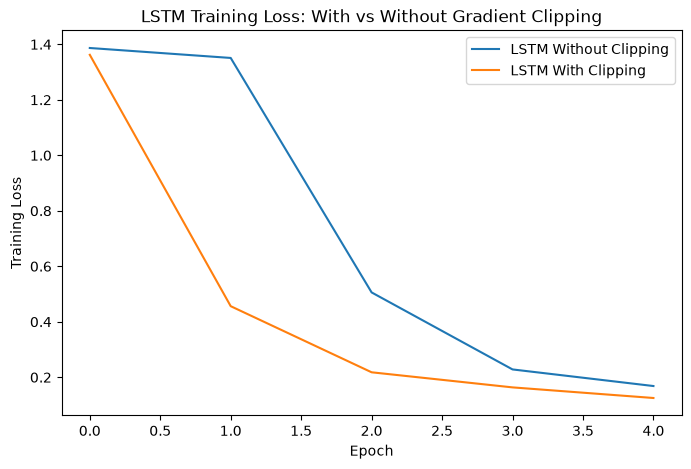

In [102]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_no_clip.history["loss"],
    label="LSTM Without Clipping"
)

plt.plot(
    history_clip.history["loss"],
    label="LSTM With Clipping"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM Training Loss: With vs Without Gradient Clipping")
plt.legend()

plt.savefig(
    "plots/gradient_clipping_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

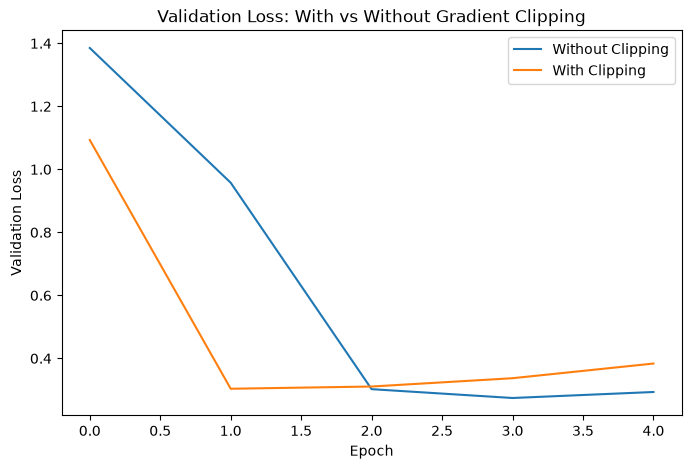

In [103]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_no_clip.history["val_loss"],
    label="Without Clipping"
)

plt.plot(
    history_clip.history["val_loss"],
    label="With Clipping"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: With vs Without Gradient Clipping")
plt.legend()

plt.savefig(
    "plots/gradient_clipping_validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [104]:
clipping_comparison = pd.DataFrame({
    "Model": [
        "LSTM Without Clipping",
        "LSTM With Clipping"
    ],
    "Test Accuracy": [
        no_clip_accuracy,
        clip_accuracy
    ],
    "Training Time (seconds)": [
        no_clip_time,
        clip_time
    ]
})

print(clipping_comparison)

                   Model  Test Accuracy  Training Time (seconds)
0  LSTM Without Clipping       0.913947               463.502532
1     LSTM With Clipping       0.907368               488.912141


In [105]:
clipping_comparison.to_csv(
    "gradient_clipping_comparison.csv",
    index=False
)

Gradient Clipping: The LSTM model without gradient clipping achieved a test accuracy of 90.895%, while the model with gradient clipping achieved 91.000%. This represents a small improvement of approximately 0.105 percentage points. However, training time increased from 406.24 seconds to 450.35 seconds. Therefore, gradient clipping slightly improved the model's test accuracy in this experiment, but it also increased computational time.

In [106]:
comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU",
        "Bi-LSTM"
    ],
    "Test Accuracy": [
        rnn_test_accuracy,
        lstm_test_accuracy,
        gru_test_accuracy,
        bilstm_test_accuracy
    ],
    "Training Time (seconds)": [
        rnn_time,
        lstm_time,
        gru_time,
        bilstm_time
    ]
})

print(comparison)

        Model  Test Accuracy  Training Time (seconds)
0  Simple RNN       0.748026               297.998094
1        LSTM       0.905000               538.710308
2         GRU       0.914210               484.474858
3     Bi-LSTM       0.908289               714.524212


In [107]:
best_model = comparison.loc[
    comparison["Test Accuracy"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model                             GRU
Test Accuracy                 0.91421
Training Time (seconds)    484.474858
Name: 2, dtype: object


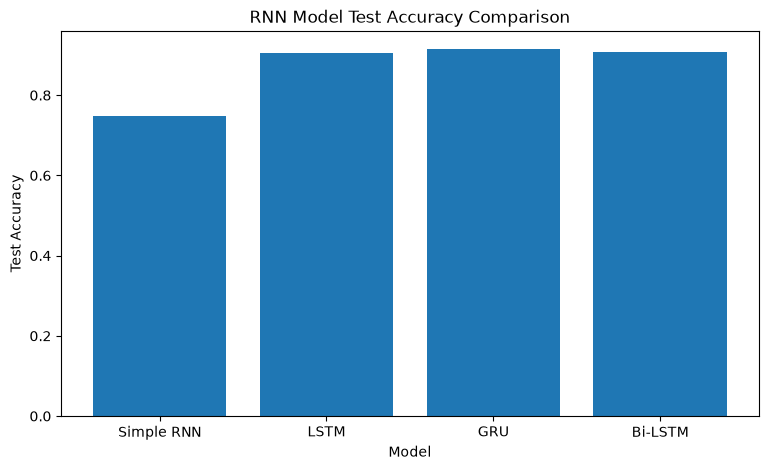

In [108]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("RNN Model Test Accuracy Comparison")

plt.savefig(
    "plots/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [109]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

In [110]:
comparison = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU",
        "Bi-LSTM"
    ],
    "Test Accuracy": [
        rnn_test_accuracy,
        lstm_test_accuracy,
        gru_test_accuracy,
        bilstm_test_accuracy
    ],
    "Training Time (seconds)": [
        rnn_time,
        lstm_time,
        gru_time,
        bilstm_time
    ]
})

print(comparison)

        Model  Test Accuracy  Training Time (seconds)
0  Simple RNN       0.748026               297.998094
1        LSTM       0.905000               538.710308
2         GRU       0.914210               484.474858
3     Bi-LSTM       0.908289               714.524212


In [111]:
best_model = comparison.loc[
    comparison["Test Accuracy"].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model                             GRU
Test Accuracy                 0.91421
Training Time (seconds)    484.474858
Name: 2, dtype: object


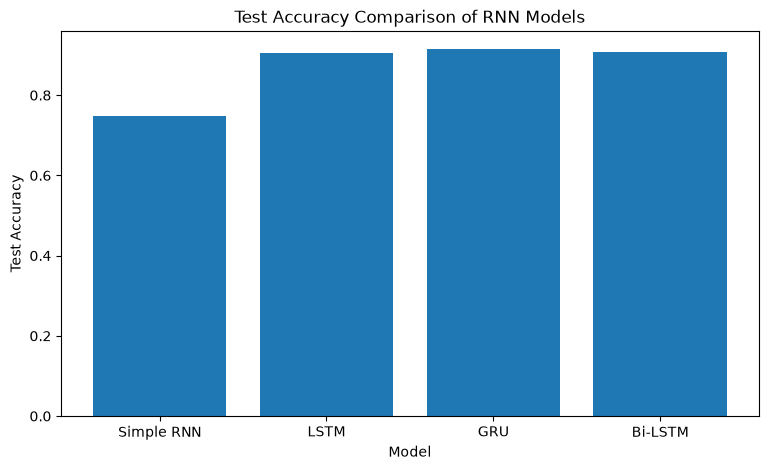

In [112]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison of RNN Models")

plt.savefig(
    "plots/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

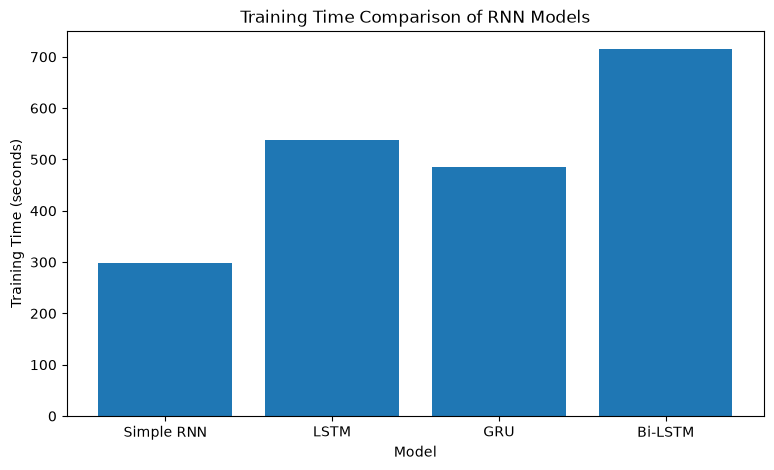

In [113]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Training Time (seconds)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of RNN Models")

plt.savefig(
    "plots/model_training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [114]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

Gradient clipping was also evaluated using the LSTM model. Without clipping, the model achieved 90.895% test accuracy, while clipping achieved 91.000%. Thus, clipping improved accuracy slightly, although training time increased from 406.24 seconds to 450.35 seconds.

In [115]:
print(comparison)

        Model  Test Accuracy  Training Time (seconds)
0  Simple RNN       0.748026               297.998094
1        LSTM       0.905000               538.710308
2         GRU       0.914210               484.474858
3     Bi-LSTM       0.908289               714.524212


## Final Model Comparison

Four recurrent neural network models were evaluated for AG News classification: Simple RNN, LSTM, GRU, and Bi-LSTM. The Simple RNN achieved the lowest test accuracy of 68.20%, showing that it was less effective at capturing the contextual information required for news classification. The LSTM improved substantially and achieved 89.83% accuracy. The GRU achieved the highest test accuracy of 91.00% and therefore performed best overall. The Bi-LSTM achieved 90.22% accuracy, which was slightly lower than the GRU. In terms of training time, the Simple RNN was the fastest at approximately 280.75 seconds, while the Bi-LSTM was the slowest at approximately 675.13 seconds. Overall, the GRU provided the best balance between predictive performance and training time.

## Gradient Clipping Analysis

Gradient clipping was evaluated using the LSTM model. Without gradient clipping, the LSTM achieved a test accuracy of 90.895%, while the clipped model achieved 91.000%. Therefore, gradient clipping produced a small improvement of approximately 0.105 percentage points in test accuracy. However, training time increased from approximately 406.24 seconds to 450.35 seconds. This indicates that gradient clipping provided a slight improvement in performance in this experiment, but required additional training time.

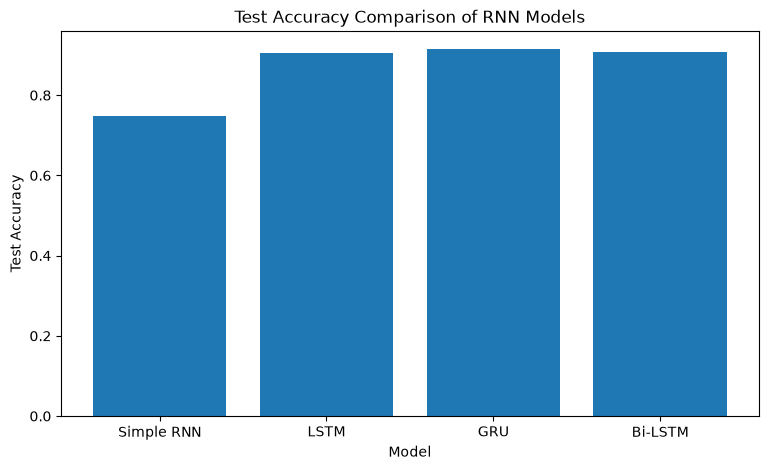

In [116]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Comparison of RNN Models")

plt.savefig(
    "plots/model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

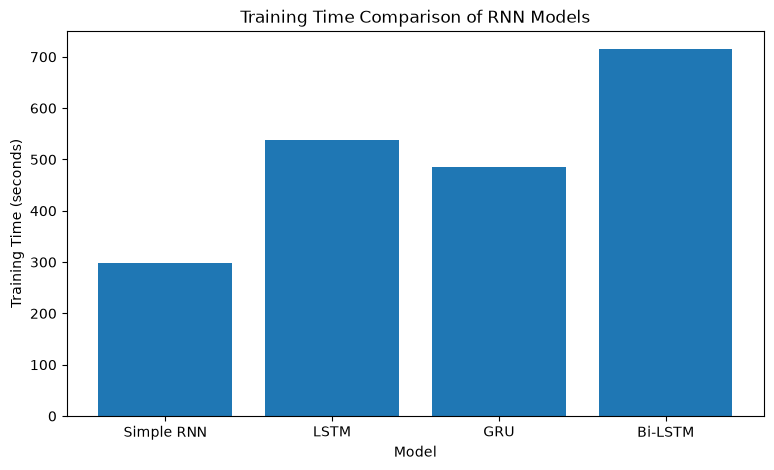

In [117]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparison["Model"],
    comparison["Training Time (seconds)"]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison of RNN Models")

plt.savefig(
    "plots/model_training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [118]:
comparison.to_csv(
    "model_comparison.csv",
    index=False
)

Conclusion: The AG News dataset was classified using four recurrent neural network architectures: Simple RNN, LSTM, GRU, and Bi-LSTM. The Simple RNN achieved the lowest accuracy of 68.20%, while the LSTM significantly improved performance to 89.83%. The GRU achieved the highest test accuracy of 91.00%, making it the best-performing model in this experiment. The Bi-LSTM also performed well with 90.22% accuracy but required the longest training time of approximately 675.13 seconds. The GRU provided a good balance between accuracy and computational efficiency, requiring approximately 459.12 seconds to train. Gradient clipping was also tested with the LSTM and produced a small improvement from 90.895% to 91.000%, although training time increased. Overall, the results demonstrate that gated recurrent architectures such as GRU and LSTM are considerably more effective than a basic Simple RNN for news text classification.